# FreeSurfer 3: group comparison analysis based on Z scores

We have a series of notebooks to demonstrate some standard analyses with FreeSurfer.  
This notebooks shows how to run a group comparison colocalization analysis using not a group-vs-group effect size map but z score maps for every individual case subject. This allows follow-up analyses (e.g., correlations) on the level of individual subjects from the target (disease) cohort.  
The approach was initially described in the [JuSpace publication](https://doi.org/10.1002/hbm.25244).

The data was prepared in the [data preparation notebook](freesurfer_1_prepare.ipynb).
The first analyses based on effect size maps was shown in [FreeSurfer: run a group comparison analysis](freesurfer_2_cross-sectional_effsize.ipynb)

In [1]:
# general imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# monkey patch to make progress bars show as ASCII instead of as widgets
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm
tqdm = tqdm.notebook.tqdm

In [2]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS LOCALLY AFTER INSTALLING NISPACE
import sys
sys.path.append("/Users/llotter/projects/nispace/")

## Load data

We prepared the data before and will only load the baseline data for the CB and HC groups

In [3]:
# cortical thickness data
df_cortex = pd.read_csv(Path.cwd() / "freesurfer_ct_baseline.csv", index_col=0)

# covariates
df_covariates = pd.read_csv(Path.cwd() / "freesurfer_cov_baseline.csv", index_col=0)

# participants df
df_participants = pd.read_csv(Path.cwd() / "freesurfer_participants.csv", index_col=0)
# subset to available subjects
df_participants = df_participants.loc[df_cortex.index]

## Perform colocalization with individual Z scores

Only cortical thickness data here.  
This will basically be the same as in the prior notebook but with a different setting for comparison_method.  
The function will now calculate a parcel-wise Z score map for every CB subject relative to the HC cohort, resulting in not one vector with colocalization values but one vector for every CB subject.

,groups,age,sex,euler_number,eTIV
subject,,,,,
sub-101,a,24.44,male,16.0,1.562223e+06
sub-103,a,24.33,male,42.0,1.692744e+06
sub-104,a,17.90,female,35.0,1.384595e+06
sub-108,a,19.39,male,53.0,1.661247e+06
sub-109,a,20.38,male,23.0,1.621123e+06


INFO | 23/04/26 15:35:21 | nispace: Loading integrated pet dataset as X data.
INFO | 23/04/26 15:35:21 | nispace: Using collection UniqueTracers.
INFO | 23/04/26 15:35:21 | nispace: Loading pet maps.
INFO | 23/04/26 15:35:21 | nispace: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 23/04/26 15:35:21 | nispace: Filtering maps by collection.
INFO | 23/04/26 15:35:21 | nispace: Loading data parcellated with 'DesikanKilliany'
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", "fsaverage", or "fsLR"), 
they are downloaded from the NiSpace-data GitHub repo (find them in 

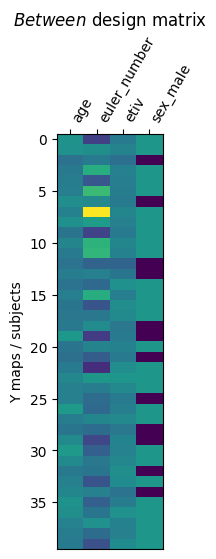

INFO | 23/04/26 15:35:22 | nispace: Protecting 1 variable(s) during regression: ['groups_b'].
INFO | 23/04/26 15:35:22 | nispace: Regressing 4 between covariate(s) from Y.


Regressing 4 between covariate(s) from Y, protecting 1 variable(s) (-1 proc): 100%|██████████| 68/68 [00:10<00:00,  6.53it/s]


INFO | 23/04/26 15:35:32 | nispace: *** NiSpace.transform_y() - Y transformation and comparison. ***
INFO | 23/04/26 15:35:32 | nispace: Groups/sessions vector provided, ensuring dummy-coding.
INFO | 23/04/26 15:35:32 | nispace: Applying Y transform 'rzscore(a,b)'.
INFO | 23/04/26 15:35:32 | nispace: rzscore: reference group has n=21 subjects. MAD estimates can be variable at this sample size.
INFO | 23/04/26 15:35:34 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 23/04/26 15:35:34 | nispace: Running 'spearman' colocalization with 'rzscore(a,b)' transform.
INFO | 23/04/26 15:35:34 | nispace: Pre-ranking X and Y data.


Colocalizing (spearman, -1 proc): 100%|██████████| 19/19 [00:00<00:00, 40.43it/s]

INFO | 23/04/26 15:35:34 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 23/04/26 15:35:34 | nispace: Permutation of: Y groups.
INFO | 23/04/26 15:35:34 | nispace: Using default null method 'alexander_bloch' (parcellation null space: 'fsLR').
INFO | 23/04/26 15:35:34 | nispace: Loading transformed Y data, transform = 'rzscore(a,b)'.
INFO | 23/04/26 15:35:34 | nispace: Will calculate p values for mean calculation across Y maps. Set 'p_from_average_y_coloc' = False to change this behavior.
INFO | 23/04/26 15:35:34 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 23/04/26 15:35:34 | nispace: Generating permuted Y groups.
INFO | 23/04/26 15:35:34 | nispace: Permuting groups/sessions vector, strategy: unpaired, proportional.



Null transformations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:00<00:00, 24475.72it/s]


INFO | 23/04/26 15:35:35 | nispace: Pre-ranking X and Y (null) data.


Null colocalizations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:02<00:00, 3383.58it/s]


INFO | 23/04/26 15:35:41 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 23/04/26 15:35:41 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 23/04/26 15:35:41 | nispace: Correction method: 'meff_galwey', alpha: 0.05, dimension: 'array'.
INFO | 23/04/26 15:35:41 | nispace: Meff_X (galwey) = 10.48 (from 29 maps).
INFO | 23/04/26 15:35:41 | nispace: *** NiSpace.normalize_colocalizations() - Normalize colocalizations against null distribution. ***
INFO | 23/04/26 15:35:41 | nispace: Z-score method: robust (median/MAD).
INFO | 23/04/26 15:35:41 | nispace: Stored normalized colocalizations: xdimred-false_ytrans-rzscore(a,b)_coloc-spearman_stat-rho_xsea-false_perm-groups
INFO | 23/04/26 15:35:41 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 23/04/26 15:35:42 | nispace: Creating categorical plot for method spearman, colocalization stat rho.
INFO | 23/04/26 15:35:43 | nispace: Significance annotation: 1/29

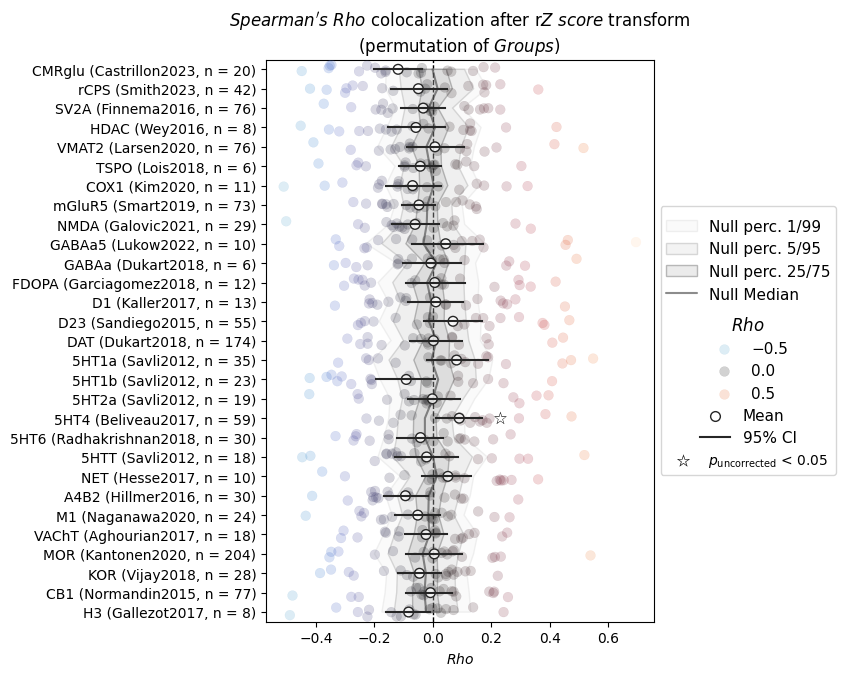

INFO | 23/04/26 15:35:43 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM  | 
| spearman | False | False       | rzscore(a,b) | 
INFO | 23/04/26 15:35:43 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM  | 
| spearman | groups       | False | None      | False       | rzscore(a,b) | 
INFO | 23/04/26 15:35:43 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM  | 
| spearman | groups       | False | meffgalwey | False       | rzscore(a,b) | 


In [4]:
from nispace.workflows import group_comparison

# design with covariates
design = pd.DataFrame({
    "groups": df_participants.group.map({"CB":"a", "HC":"b"}), 
    "age": df_participants["age at baseline "], 
    "sex": df_participants["gender"], 
    "euler_number": df_covariates["SurfaceHoles"],
    "eTIV": df_covariates["EstimatedTotalIntraCranialVol"]
})
display(design.head(5))

# run
colocs, pvalues, qvalues, nsp_object = group_comparison(
    y=df_cortex, # sample data
    x="pet", # reference data
    parcellation="Desikan", # parcellation
    design=design, # group membership
    comparison_method="rzscore(a,b)", # NOTE: this was "hedges(a,b)" before and is the major change
    colocalization_method="spearman", # spearman correlation btw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=True,
    seed=42
)

The outputs of the workflow function now are:
- `colocs`: the correlation coefficients between the Z score maps for every CB subject and the reference data across parcels
- `pvalues`: the p values calculated for the mean of the correlation coefficients, i.e., indexing the *group* effect.
- `qvalues`: the FDR-corrected p values for each correlation coefficient
- `nsp_object`: the NiSpace object, which contains the results and can be used for further analyses  

We will print the first three dataframes:

In [5]:
display("Colocalization:", colocs)
display("p values:", pvalues)
display("q values:", qvalues)

'Colocalization:'

set                                                    General  \
map     target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
subject                                                          
sub-101                                          -0.356253       
sub-103                                           0.173299       
sub-104                                          -0.161366       
sub-108                                          -0.352583       
sub-109                                           0.062685       
sub-112                                           0.050201       
sub-116                                           0.212797       
sub-117                                          -0.048708       
sub-119                                          -0.089446       
sub-121                                           0.137439       
sub-123                                          -0.176723       
sub-124                                          -0.162111       
sub-125                                          -0.040599       
sub-126                                          -0.252351       
sub-127                                          -0.037465       
sub-128                                          -0.224726       
sub-130                                          -0.346731       
sub-132                                          -0.197553       
sub-133                                          -0.448307       

set                                                          \
map     target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
subject                                                       
sub-101                                          -0.419982    
sub-103                                           0.360279    
sub-104                                          -0.026230    
sub-108                                          -0.300145    
sub-109                                           0.182083    
sub-112                                           0.176329    
sub-116                                           0.121253    
sub-117                                           0.171883    
sub-119                                          -0.042856    
sub-121                                           0.230472    
sub-123                                          -0.239504    
sub-124                                          -0.135573    
sub-125                                           0.040982    
sub-126                                          -0.173220    
sub-127                                           0.063604    
sub-128                                          -0.363012    
sub-130                                          -0.274141    
sub-132                                          -0.019318    
sub-133                                          -0.295521    

set                                                         \
map     target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
subject                                                      
sub-101                                           0.174558   
sub-103                                           0.230311   
sub-104                                          -0.002443   
sub-108                                          -0.137439   
sub-109                                           0.107524   
sub-112                                           0.161131   
sub-116                                           0.122222   
sub-117                                           0.189154   
sub-119                                          -0.170311   
sub-121                                          -0.068512   
sub-123                                          -0.154127   
sub-124                                          -0.029936   
sub-125                                          -0.022831   
sub-126                                           0.004810   
sub-127                                          -0.195411   
sub-128                                     

'p values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                             0.0882       

set                                                       \
map  target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
mean                                             0.4012    

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
mean                                               0.72   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                             0.3652     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                             0.6844   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                          0.5464   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                          0.318   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                              0.557     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                              0.489    

set                                                    GABA  ...  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022  ...   
mean                                             0.3898      ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                             0.7928              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                           0.7974   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                         0.4908   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                             0.2288        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                             0.5114        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                             0.8828       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                             0.5836           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                              0.711     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                             0.7592    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                             0.3814     

[1 rows x 29 columns]

'q values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                           0.620183       

set                                                       \
map  target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
mean                                           0.995377    

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
mean                                           0.999998   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                           0.991473     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                           0.999994   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                        0.999749   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                       0.981914   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                           0.999804     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                           0.999123    

set                                                    GABA  ...  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022  ...   
mean                                           0.994366      ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                                1.0              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                              1.0   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                       0.999155   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                           0.934382        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                           0.999452        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                                1.0       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                           0.999897           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                           0.999998     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                                1.0    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                           0.993498     

[1 rows x 29 columns]

There we go! Nothing significant (too bad), but the order of effects remains the same as with the effect size-based method.

In [6]:
pvalues.T["mean"].sort_values().head(6)

set                          map                                                    
Serotonin                    target-5HT4_tracer-sb207145_n-59_dx-hc_pub-beliveau2017    0.0422
General                      target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023     0.0882
Serotonin                    target-5HT1b_tracer-p943_n-23_dx-hc_pub-savli2012          0.1946
Noradrenaline/Acetylcholine  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016    0.2288
Dopamine                     target-D23_tracer-flb457_n-55_dx-hc_pub-sandiego2015       0.2868
Immunity                     target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020             0.3180
Name: mean, dtype: float32

## Post-hoc analyses

As mentioned above, if using the "zscore" group comparison method, we can perform post-hoc analyses on the single-subject correlation coefficients. This just serves to demonstrate how to work with the colocalization results. 

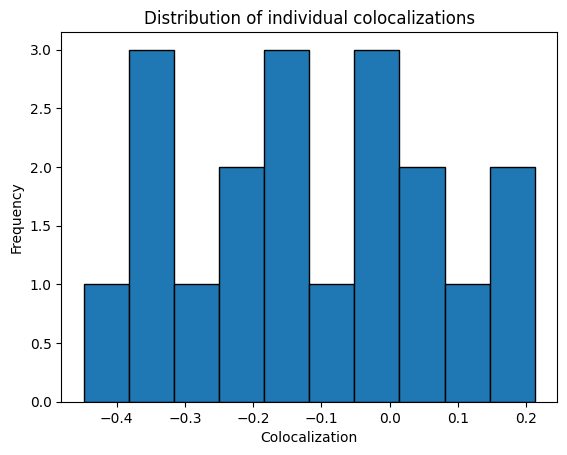

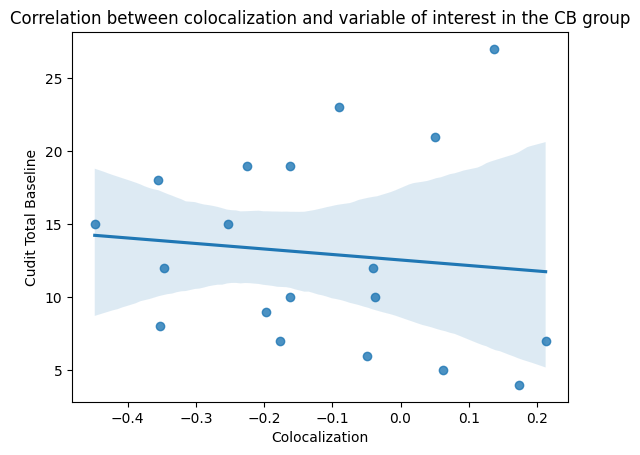

In [7]:
from seaborn import regplot

# define targets
reference_map = ('General', 'target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023')
variable_of_interest = "cudit total baseline"

# colocalizations for CB1
colocs_individual = colocs.loc[:, reference_map]

# show the distributions of these values
colocs_individual.plot.hist(legend=False, title="Distribution of individual colocalizations", edgecolor="k")
plt.xlabel(f"Colocalization")
plt.show()

# Example:
regplot(
    x=colocs_individual,
    y=df_participants.query("group=='CB'")[variable_of_interest],
)
plt.ylabel(variable_of_interest.title())
plt.xlabel("Colocalization")
_ = plt.title("Correlation between colocalization and variable of interest in the CB group")
